In [50]:
import numpy as np
import pandas as pd
import panel as pn
pn.extension()

In [51]:
@pn.cache
def get_data():
  return pd.read_csv("output_main.csv")

In [52]:
df=get_data().fillna("NaN")

In [104]:
VARIABLES = ["dtype", "seq_desc_format"]
def _selector_widgets():
    for cat in ("attn_bias_type", "attn_mask_type", "qkv_layout", "bias_shape", "is_training","swa", "dropout"):
        yield pn.widgets.Select(name=cat, options=list(df[cat].unique()))


selector_widgets = list(_selector_widgets())


In [55]:
import seaborn as sns

In [113]:
def make_plot(attn_bias_type, attn_mask_type, qkv_layout, bias_shape, is_training, swa, dropout):
    subset = df[
        (
            (df["attn_bias_type"]==attn_bias_type) &
            (df["attn_mask_type"]==attn_mask_type) &
            (df["qkv_layout"]==qkv_layout) &
            (df["bias_shape"]==bias_shape) &
            (df["is_training"]==is_training) &
            (df["swa"]==swa) &
            (df["dropout"]==dropout)
        )
    ]
    subset = subset[subset.time < subset.time.quantile(.95)]
    subset = subset[subset.time > subset.time.quantile(.05)]
    if not subset.empty:
        return sns.catplot(data=subset, kind="violin", x="seq_desc_format", y="time", hue="dtype", split=True)

Row
    [0] Column
        [0] Select(name='attn_bias_type', options=['AttnBiasType.NO_BIAS', ...], value='AttnBiasType.NO_BIAS')
        [1] Select(name='attn_mask_type', options=['AttnMaskType.NO_MASK', ...], value='AttnMaskType.NO_MASK')
        [2] Select(name='qkv_layout', options=['QKVLayout.BS3HD', ...], value='QKVLayout.BS3HD')
        [3] Select(name='bias_shape', options=['NaN', 'BiasShape._1HSS']...], value='NaN')
        [4] Select(name='is_training', options=[True, False], value=True)
        [5] Select(name='swa', options=[True, False], value=True)
        [6] Select(name='dropout', options=[0.0, 0.1], value=0.0)
    [1] ParamFunction(function, _pane=Str, defer_load=False)

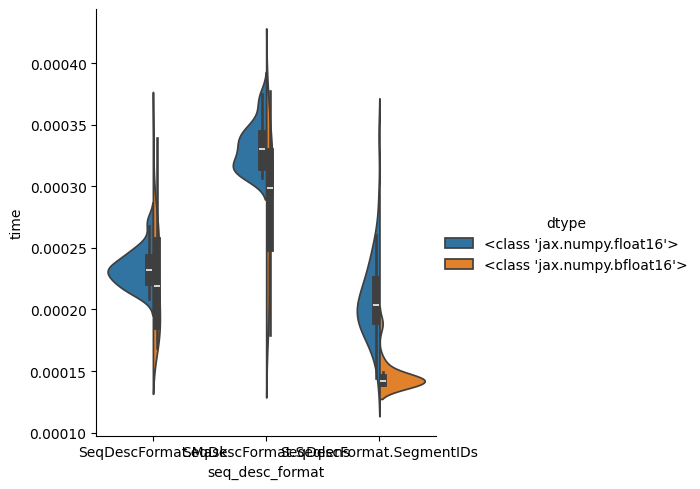

In [115]:
bound_make_plot = pn.bind(make_plot, 
        attn_bias_type=selector_widgets[0],
        attn_mask_type=selector_widgets[1],
        qkv_layout=selector_widgets[2],
        bias_shape=selector_widgets[3],
        is_training=selector_widgets[4],
        swa=selector_widgets[5],
        dropout=selector_widgets[6],
)
pn.Row(
    pn.Column(*selector_widgets),
    bound_make_plot
).servable()